In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm
from sklearn.metrics import classification_report

In [ ]:
dataset = pd.read_excel("Clustering.xlsx")
X = dataset.iloc[:, [1, 2]].values #KMeans Clustering
x1 = dataset.iloc[:, [2]].values #Confusion Matrix

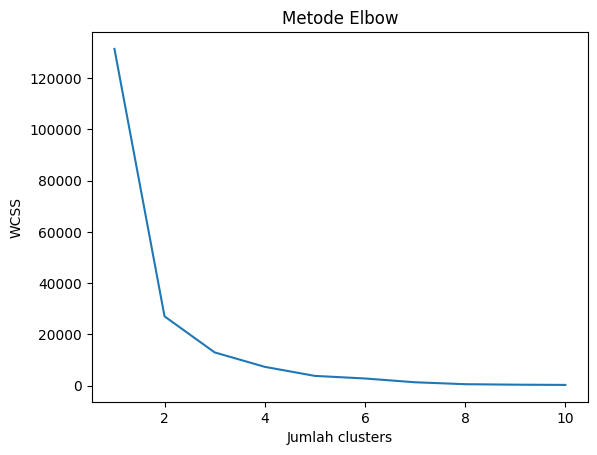

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Metode Elbow')
plt.xlabel('Jumlah clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)
y_kmeans

array([2, 2, 0, 0, 0, 2, 0, 2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

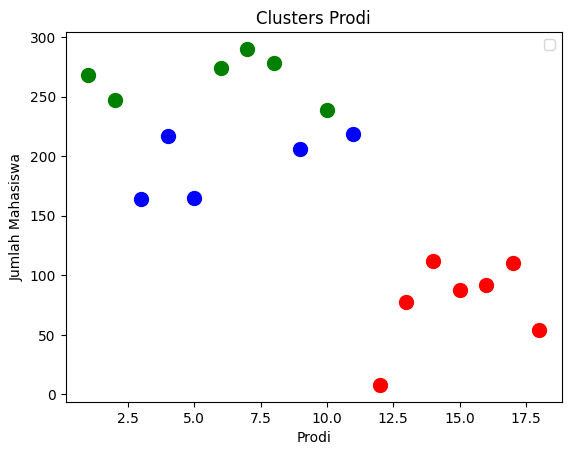

In [ ]:
# Visualisasi hasil clusters
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'red')
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'blue')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green')
plt.title('Clusters Prodi')
plt.xlabel('Prodi')
plt.ylabel('Jumlah Mahasiswa')
plt.legend()
plt.show()


In [ ]:
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x1, y_kmeans, test_size = 0.2, random_state = 42)

In [ ]:
#menggunakan SVM library untuk membuat SVM classifier
classifier = svm.SVC(kernel = 'linear')

#memasukkan training data kedalam classifier
classifier.fit(X_train, y_train)

#memasukkan testing data ke variabel y_predict
y_predict = classifier.predict(X_test)


In [ ]:
#Prediksi hasil akurasi
from sklearn import metrics
y_pred = classifier.predict(X_test)
print("hasil akurasi :", metrics.accuracy_score(y_test,y_pred))

hasil akurasi : 1.0


[[1 0]
 [0 3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



<Axes: >

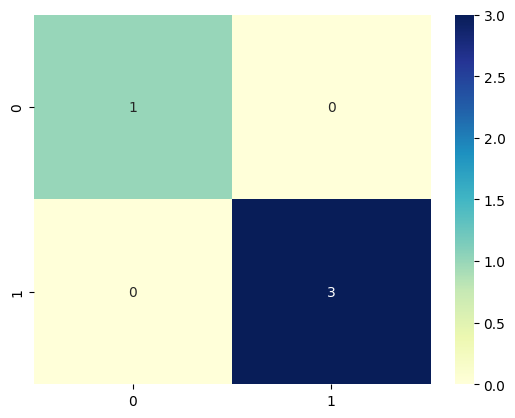

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix , classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))
sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'YlGnBu')